### Final Capstone Project: Azure Databricks
**Healthcare Analytics Platform**

In [0]:
dbutils.fs.mkdirs("dbfs:/FileStore/tables/healthcare_raw/")

True

Part 1: Data Ingestion


In [0]:
patients_data = """patient_id,patient_name,patient_city,state,age,gender,insurance_status
P101, Rahul Sharma, Hyderabad, Telangana, 35, Male, Active
P102, Priya Reddy, Bangalore, Karnataka, 29, Female, Active
P103, Amit Kumar, Mumbai, Maharashtra, 42, Male, Inactive
P104, Sneha Patel, Delhi, Delhi, 31, Female, Active
P105, Farhan Ali, Chennai, Tamil Nadu, 55, Male, Active
P106, Neha Singh, Pune, Maharashtra, 38, Female, Inactive
P107, Arjun Verma, Hyderabad, Telangana, 26, Male, Active
P108, Meera Nair, Kochi, Kerala, 48, Female, Active"""
dbutils.fs.put("dbfs:/FileStore/tables/healthcare_raw/patients.csv", patients_data, overwrite=True)

doctors_data = """doctor_id,doctor_name,department,city,consultation_fee
D101, Dr. Ramesh, Cardiology, Hyderabad, 1500
D102, Dr. Priya, Neurology, Bangalore, 2000
D103, Dr. Anita, Dermatology, Chennai, 1000
D104, Dr. Suresh, Orthopedics, Mumbai, 2500
D105, Dr. Meera, Pediatrics, Delhi, 1200
D106, Dr. Kiran, Cardiology, Hyderabad, 3000"""
dbutils.fs.put("dbfs:/FileStore/tables/healthcare_raw/doctors.csv", doctors_data, overwrite=True)

appointments_data = """appointment_id,patient_id,doctor_id,appointment_date,diagnosis,bill_amount,status
A1001,P101,D101,2026-06-01,Heart Checkup,5000,Completed
A1002,P102,D102,2026-06-01,Migraine,3500,Completed
A1003,P103,D103,2026-06-02,Skin Allergy,2000,Pending
A1004,P104,D104,2026-06-02,Fracture,12000,Completed
A1005,P105,D105,2026-06-03,Fever,1500,Completed
A1006,P106,D106,2026-06-03,Heart Checkup,7000,Completed
A1007,P107,D101,2026-06-04,Chest Pain,5500,Completed
A1008,P108,D103,2026-06-04,Skin Infection,2500,Pending
A1009,P101,D106,2026-06-05,Cardiac Review,6500,Completed
A1010,P104,D104,2026-06-05,Back Pain,4500,Cancelled"""
dbutils.fs.put("dbfs:/FileStore/tables/healthcare_raw/appointments.csv", appointments_data, overwrite=True)

patient_pref_data = """[
  {"patient_id": "P101", "preferred_hospital": "Apollo Hospital", "contact": {"phone": "9876500011", "email": "rahul@mail.com"}},
  {"patient_id": "P102", "preferred_hospital": "Yashoda Hospital", "contact": {"phone": "9876500012", "email": "priya@mail.com"}},
  {"patient_id": "P104", "preferred_hospital": "Care Hospital", "contact": {"phone": "9876500014", "email": "sneha@mail.com"}},
  {"patient_id": "P108", "preferred_hospital": "Apollo Hospital", "contact": {"phone": "9876500018", "email": "meera@mail.com"}}
]"""
dbutils.fs.put("dbfs:/FileStore/tables/healthcare_raw/patient_preferences.json", patient_pref_data, overwrite=True)

Wrote 523 bytes.
Wrote 318 bytes.
Wrote 614 bytes.
Wrote 521 bytes.


True

In [0]:
patients_df = spark.read.csv("dbfs:/FileStore/tables/healthcare_raw/patients.csv", header=True, inferSchema=True)
display(patients_df)

doctors_df = spark.read.csv("dbfs:/FileStore/tables/healthcare_raw/doctors.csv", header=True, inferSchema=True)
display(doctors_df)

appointments_df = spark.read.csv("dbfs:/FileStore/tables/healthcare_raw/appointments.csv", header=True, inferSchema=True)
display(appointments_df)

patient_preferences_df = spark.read.option("multiline", "true").json("dbfs:/FileStore/tables/healthcare_raw/patient_preferences.json")
display(patient_preferences_df)

patient_id,patient_name,patient_city,state,age,gender,insurance_status
P101,Rahul Sharma,Hyderabad,Telangana,35.0,Male,Active
P102,Priya Reddy,Bangalore,Karnataka,29.0,Female,Active
P103,Amit Kumar,Mumbai,Maharashtra,42.0,Male,Inactive
P104,Sneha Patel,Delhi,Delhi,31.0,Female,Active
P105,Farhan Ali,Chennai,Tamil Nadu,55.0,Male,Active
P106,Neha Singh,Pune,Maharashtra,38.0,Female,Inactive
P107,Arjun Verma,Hyderabad,Telangana,26.0,Male,Active
P108,Meera Nair,Kochi,Kerala,48.0,Female,Active


doctor_id,doctor_name,department,city,consultation_fee
D101,Dr. Ramesh,Cardiology,Hyderabad,1500.0
D102,Dr. Priya,Neurology,Bangalore,2000.0
D103,Dr. Anita,Dermatology,Chennai,1000.0
D104,Dr. Suresh,Orthopedics,Mumbai,2500.0
D105,Dr. Meera,Pediatrics,Delhi,1200.0
D106,Dr. Kiran,Cardiology,Hyderabad,3000.0


appointment_id,patient_id,doctor_id,appointment_date,diagnosis,bill_amount,status
A1001,P101,D101,2026-06-01,Heart Checkup,5000,Completed
A1002,P102,D102,2026-06-01,Migraine,3500,Completed
A1003,P103,D103,2026-06-02,Skin Allergy,2000,Pending
A1004,P104,D104,2026-06-02,Fracture,12000,Completed
A1005,P105,D105,2026-06-03,Fever,1500,Completed
A1006,P106,D106,2026-06-03,Heart Checkup,7000,Completed
A1007,P107,D101,2026-06-04,Chest Pain,5500,Completed
A1008,P108,D103,2026-06-04,Skin Infection,2500,Pending
A1009,P101,D106,2026-06-05,Cardiac Review,6500,Completed
A1010,P104,D104,2026-06-05,Back Pain,4500,Cancelled


contact,patient_id,preferred_hospital
"List(rahul@mail.com, 9876500011)",P101,Apollo Hospital
"List(priya@mail.com, 9876500012)",P102,Yashoda Hospital
"List(sneha@mail.com, 9876500014)",P104,Care Hospital
"List(meera@mail.com, 9876500018)",P108,Apollo Hospital


In [0]:
# Schemas
patients_df.printSchema()
doctors_df.printSchema()
appointments_df.printSchema()
patient_preferences_df.printSchema()

root
 |-- patient_id: string (nullable = true)
 |-- patient_name: string (nullable = true)
 |-- patient_city: string (nullable = true)
 |-- state: string (nullable = true)
 |-- age: double (nullable = true)
 |-- gender: string (nullable = true)
 |-- insurance_status: string (nullable = true)

root
 |-- doctor_id: string (nullable = true)
 |-- doctor_name: string (nullable = true)
 |-- department: string (nullable = true)
 |-- city: string (nullable = true)
 |-- consultation_fee: double (nullable = true)

root
 |-- appointment_id: string (nullable = true)
 |-- patient_id: string (nullable = true)
 |-- doctor_id: string (nullable = true)
 |-- appointment_date: date (nullable = true)
 |-- diagnosis: string (nullable = true)
 |-- bill_amount: integer (nullable = true)
 |-- status: string (nullable = true)

root
 |-- contact: struct (nullable = true)
 |    |-- email: string (nullable = true)
 |    |-- phone: string (nullable = true)
 |-- patient_id: string (nullable = true)
 |-- preferred_h

In [0]:
patients_df.write.format("delta").mode("overwrite").saveAsTable("bronze_patients")
doctors_df.write.format("delta").mode("overwrite").saveAsTable("bronze_doctors")
appointments_df.write.format("delta").mode("overwrite").saveAsTable("bronze_appointments")
patient_preferences_df.write.format("delta").mode("overwrite").saveAsTable("bronze_patient_preferences")

Part 2: Data Cleaning and Transformation


In [0]:
from pyspark.sql.functions import *

patients_cleaned = patients_df.na.drop(subset=["patient_id"])
doctors_cleaned = doctors_df.na.drop(subset=["doctor_id"])
appointments_cleaned = appointments_df.na.drop(subset=["appointment_id"])

In [0]:
flattened_patient_preferences = patient_preferences_df.select(
    col("patient_id"),
    col("preferred_hospital"),
    col("contact.phone").alias("patient_phone"),
    col("contact.email").alias("patient_email")
)
display(flattened_patient_preferences)

patient_id,preferred_hospital,patient_phone,patient_email
P101,Apollo Hospital,9876500011,rahul@mail.com
P102,Yashoda Hospital,9876500012,priya@mail.com
P104,Care Hospital,9876500014,sneha@mail.com
P108,Apollo Hospital,9876500018,meera@mail.com


In [0]:
pat_pref = patients_cleaned.join(flattened_patient_preferences, "patient_id", "left")
display(pat_pref)

pat_pref_cleaned = pat_pref.na.fill({
    "preferred_hospital": "Unknown",
    "patient_phone": "Not Available",
    "patient_email": "Not Available"
})
display(pat_pref_cleaned)

patient_id,patient_name,patient_city,state,age,gender,insurance_status,preferred_hospital,patient_phone,patient_email
P101,Rahul Sharma,Hyderabad,Telangana,35.0,Male,Active,Apollo Hospital,9876500011,rahul@mail.com
P102,Priya Reddy,Bangalore,Karnataka,29.0,Female,Active,Yashoda Hospital,9876500012,priya@mail.com
P103,Amit Kumar,Mumbai,Maharashtra,42.0,Male,Inactive,null,null,null
P104,Sneha Patel,Delhi,Delhi,31.0,Female,Active,Care Hospital,9876500014,sneha@mail.com
P105,Farhan Ali,Chennai,Tamil Nadu,55.0,Male,Active,null,null,null
P106,Neha Singh,Pune,Maharashtra,38.0,Female,Inactive,null,null,null
P107,Arjun Verma,Hyderabad,Telangana,26.0,Male,Active,null,null,null
P108,Meera Nair,Kochi,Kerala,48.0,Female,Active,Apollo Hospital,9876500018,meera@mail.com


patient_id,patient_name,patient_city,state,age,gender,insurance_status,preferred_hospital,patient_phone,patient_email
P101,Rahul Sharma,Hyderabad,Telangana,35.0,Male,Active,Apollo Hospital,9876500011,rahul@mail.com
P102,Priya Reddy,Bangalore,Karnataka,29.0,Female,Active,Yashoda Hospital,9876500012,priya@mail.com
P103,Amit Kumar,Mumbai,Maharashtra,42.0,Male,Inactive,Unknown,Not Available,Not Available
P104,Sneha Patel,Delhi,Delhi,31.0,Female,Active,Care Hospital,9876500014,sneha@mail.com
P105,Farhan Ali,Chennai,Tamil Nadu,55.0,Male,Active,Unknown,Not Available,Not Available
P106,Neha Singh,Pune,Maharashtra,38.0,Female,Inactive,Unknown,Not Available,Not Available
P107,Arjun Verma,Hyderabad,Telangana,26.0,Male,Active,Unknown,Not Available,Not Available
P108,Meera Nair,Kochi,Kerala,48.0,Female,Active,Apollo Hospital,9876500018,meera@mail.com


In [0]:
app_pat = appointments_cleaned.join(pat_pref_cleaned, "patient_id", "inner")
display(app_pat)

app_doc = app_pat.join(doctors_cleaned, "doctor_id", "inner")
display(app_doc)

patient_id,appointment_id,doctor_id,appointment_date,diagnosis,bill_amount,status,patient_name,patient_city,state,age,gender,insurance_status,preferred_hospital,patient_phone,patient_email
P101,A1009,D106,2026-06-05,Cardiac Review,6500,Completed,Rahul Sharma,Hyderabad,Telangana,35.0,Male,Active,Apollo Hospital,9876500011,rahul@mail.com
P102,A1002,D102,2026-06-01,Migraine,3500,Completed,Priya Reddy,Bangalore,Karnataka,29.0,Female,Active,Yashoda Hospital,9876500012,priya@mail.com
P103,A1003,D103,2026-06-02,Skin Allergy,2000,Pending,Amit Kumar,Mumbai,Maharashtra,42.0,Male,Inactive,Unknown,Not Available,Not Available
P104,A1010,D104,2026-06-05,Back Pain,4500,Cancelled,Sneha Patel,Delhi,Delhi,31.0,Female,Active,Care Hospital,9876500014,sneha@mail.com
P105,A1005,D105,2026-06-03,Fever,1500,Completed,Farhan Ali,Chennai,Tamil Nadu,55.0,Male,Active,Unknown,Not Available,Not Available
P106,A1006,D106,2026-06-03,Heart Checkup,7000,Completed,Neha Singh,Pune,Maharashtra,38.0,Female,Inactive,Unknown,Not Available,Not Available
P107,A1007,D101,2026-06-04,Chest Pain,5500,Completed,Arjun Verma,Hyderabad,Telangana,26.0,Male,Active,Unknown,Not Available,Not Available
P108,A1008,D103,2026-06-04,Skin Infection,2500,Pending,Meera Nair,Kochi,Kerala,48.0,Female,Active,Apollo Hospital,9876500018,meera@mail.com
P101,A1001,D101,2026-06-01,Heart Checkup,5000,Completed,Rahul Sharma,Hyderabad,Telangana,35.0,Male,Active,Apollo Hospital,9876500011,rahul@mail.com
P104,A1004,D104,2026-06-02,Fracture,12000,Completed,Sneha Patel,Delhi,Delhi,31.0,Female,Active,Care Hospital,9876500014,sneha@mail.com


doctor_id,patient_id,appointment_id,appointment_date,diagnosis,bill_amount,status,patient_name,patient_city,state,age,gender,insurance_status,preferred_hospital,patient_phone,patient_email,doctor_name,department,city,consultation_fee
D106,P101,A1009,2026-06-05,Cardiac Review,6500,Completed,Rahul Sharma,Hyderabad,Telangana,35.0,Male,Active,Apollo Hospital,9876500011,rahul@mail.com,Dr. Kiran,Cardiology,Hyderabad,3000.0
D102,P102,A1002,2026-06-01,Migraine,3500,Completed,Priya Reddy,Bangalore,Karnataka,29.0,Female,Active,Yashoda Hospital,9876500012,priya@mail.com,Dr. Priya,Neurology,Bangalore,2000.0
D103,P103,A1003,2026-06-02,Skin Allergy,2000,Pending,Amit Kumar,Mumbai,Maharashtra,42.0,Male,Inactive,Unknown,Not Available,Not Available,Dr. Anita,Dermatology,Chennai,1000.0
D104,P104,A1010,2026-06-05,Back Pain,4500,Cancelled,Sneha Patel,Delhi,Delhi,31.0,Female,Active,Care Hospital,9876500014,sneha@mail.com,Dr. Suresh,Orthopedics,Mumbai,2500.0
D105,P105,A1005,2026-06-03,Fever,1500,Completed,Farhan Ali,Chennai,Tamil Nadu,55.0,Male,Active,Unknown,Not Available,Not Available,Dr. Meera,Pediatrics,Delhi,1200.0
D106,P106,A1006,2026-06-03,Heart Checkup,7000,Completed,Neha Singh,Pune,Maharashtra,38.0,Female,Inactive,Unknown,Not Available,Not Available,Dr. Kiran,Cardiology,Hyderabad,3000.0
D101,P107,A1007,2026-06-04,Chest Pain,5500,Completed,Arjun Verma,Hyderabad,Telangana,26.0,Male,Active,Unknown,Not Available,Not Available,Dr. Ramesh,Cardiology,Hyderabad,1500.0
D103,P108,A1008,2026-06-04,Skin Infection,2500,Pending,Meera Nair,Kochi,Kerala,48.0,Female,Active,Apollo Hospital,9876500018,meera@mail.com,Dr. Anita,Dermatology,Chennai,1000.0
D101,P101,A1001,2026-06-01,Heart Checkup,5000,Completed,Rahul Sharma,Hyderabad,Telangana,35.0,Male,Active,Apollo Hospital,9876500011,rahul@mail.com,Dr. Ramesh,Cardiology,Hyderabad,1500.0
D104,P104,A1004,2026-06-02,Fracture,12000,Completed,Sneha Patel,Delhi,Delhi,31.0,Female,Active,Care Hospital,9876500014,sneha@mail.com,Dr. Suresh,Orthopedics,Mumbai,2500.0


In [0]:
print("Creating final_bill column:")
overall_data = app_doc.withColumn("final_bill", col("consultation_fee")+col("bill_amount"))
display(overall_data)

print("Creating appointment_month column:")
overall_data = overall_data.withColumn("appointment_month", month(col("appointment_date")))
display(overall_data)

print("Creating patient_age_group column:")
overall_data = overall_data.withColumn("patient_age_group", when(col("age")>=50,"Senior").when(col("age")>=30,"Adult").otherwise("Young"))
display(overall_data)

Creating final_bill column:


doctor_id,patient_id,appointment_id,appointment_date,diagnosis,bill_amount,status,patient_name,patient_city,state,age,gender,insurance_status,preferred_hospital,patient_phone,patient_email,doctor_name,department,city,consultation_fee,final_bill
D106,P101,A1009,2026-06-05,Cardiac Review,6500,Completed,Rahul Sharma,Hyderabad,Telangana,35.0,Male,Active,Apollo Hospital,9876500011,rahul@mail.com,Dr. Kiran,Cardiology,Hyderabad,3000.0,9500.0
D102,P102,A1002,2026-06-01,Migraine,3500,Completed,Priya Reddy,Bangalore,Karnataka,29.0,Female,Active,Yashoda Hospital,9876500012,priya@mail.com,Dr. Priya,Neurology,Bangalore,2000.0,5500.0
D103,P103,A1003,2026-06-02,Skin Allergy,2000,Pending,Amit Kumar,Mumbai,Maharashtra,42.0,Male,Inactive,Unknown,Not Available,Not Available,Dr. Anita,Dermatology,Chennai,1000.0,3000.0
D104,P104,A1010,2026-06-05,Back Pain,4500,Cancelled,Sneha Patel,Delhi,Delhi,31.0,Female,Active,Care Hospital,9876500014,sneha@mail.com,Dr. Suresh,Orthopedics,Mumbai,2500.0,7000.0
D105,P105,A1005,2026-06-03,Fever,1500,Completed,Farhan Ali,Chennai,Tamil Nadu,55.0,Male,Active,Unknown,Not Available,Not Available,Dr. Meera,Pediatrics,Delhi,1200.0,2700.0
D106,P106,A1006,2026-06-03,Heart Checkup,7000,Completed,Neha Singh,Pune,Maharashtra,38.0,Female,Inactive,Unknown,Not Available,Not Available,Dr. Kiran,Cardiology,Hyderabad,3000.0,10000.0
D101,P107,A1007,2026-06-04,Chest Pain,5500,Completed,Arjun Verma,Hyderabad,Telangana,26.0,Male,Active,Unknown,Not Available,Not Available,Dr. Ramesh,Cardiology,Hyderabad,1500.0,7000.0
D103,P108,A1008,2026-06-04,Skin Infection,2500,Pending,Meera Nair,Kochi,Kerala,48.0,Female,Active,Apollo Hospital,9876500018,meera@mail.com,Dr. Anita,Dermatology,Chennai,1000.0,3500.0
D101,P101,A1001,2026-06-01,Heart Checkup,5000,Completed,Rahul Sharma,Hyderabad,Telangana,35.0,Male,Active,Apollo Hospital,9876500011,rahul@mail.com,Dr. Ramesh,Cardiology,Hyderabad,1500.0,6500.0
D104,P104,A1004,2026-06-02,Fracture,12000,Completed,Sneha Patel,Delhi,Delhi,31.0,Female,Active,Care Hospital,9876500014,sneha@mail.com,Dr. Suresh,Orthopedics,Mumbai,2500.0,14500.0


Creating appointment_month column:


doctor_id,patient_id,appointment_id,appointment_date,diagnosis,bill_amount,status,patient_name,patient_city,state,age,gender,insurance_status,preferred_hospital,patient_phone,patient_email,doctor_name,department,city,consultation_fee,final_bill,appointment_month
D106,P101,A1009,2026-06-05,Cardiac Review,6500,Completed,Rahul Sharma,Hyderabad,Telangana,35.0,Male,Active,Apollo Hospital,9876500011,rahul@mail.com,Dr. Kiran,Cardiology,Hyderabad,3000.0,9500.0,6
D102,P102,A1002,2026-06-01,Migraine,3500,Completed,Priya Reddy,Bangalore,Karnataka,29.0,Female,Active,Yashoda Hospital,9876500012,priya@mail.com,Dr. Priya,Neurology,Bangalore,2000.0,5500.0,6
D103,P103,A1003,2026-06-02,Skin Allergy,2000,Pending,Amit Kumar,Mumbai,Maharashtra,42.0,Male,Inactive,Unknown,Not Available,Not Available,Dr. Anita,Dermatology,Chennai,1000.0,3000.0,6
D104,P104,A1010,2026-06-05,Back Pain,4500,Cancelled,Sneha Patel,Delhi,Delhi,31.0,Female,Active,Care Hospital,9876500014,sneha@mail.com,Dr. Suresh,Orthopedics,Mumbai,2500.0,7000.0,6
D105,P105,A1005,2026-06-03,Fever,1500,Completed,Farhan Ali,Chennai,Tamil Nadu,55.0,Male,Active,Unknown,Not Available,Not Available,Dr. Meera,Pediatrics,Delhi,1200.0,2700.0,6
D106,P106,A1006,2026-06-03,Heart Checkup,7000,Completed,Neha Singh,Pune,Maharashtra,38.0,Female,Inactive,Unknown,Not Available,Not Available,Dr. Kiran,Cardiology,Hyderabad,3000.0,10000.0,6
D101,P107,A1007,2026-06-04,Chest Pain,5500,Completed,Arjun Verma,Hyderabad,Telangana,26.0,Male,Active,Unknown,Not Available,Not Available,Dr. Ramesh,Cardiology,Hyderabad,1500.0,7000.0,6
D103,P108,A1008,2026-06-04,Skin Infection,2500,Pending,Meera Nair,Kochi,Kerala,48.0,Female,Active,Apollo Hospital,9876500018,meera@mail.com,Dr. Anita,Dermatology,Chennai,1000.0,3500.0,6
D101,P101,A1001,2026-06-01,Heart Checkup,5000,Completed,Rahul Sharma,Hyderabad,Telangana,35.0,Male,Active,Apollo Hospital,9876500011,rahul@mail.com,Dr. Ramesh,Cardiology,Hyderabad,1500.0,6500.0,6
D104,P104,A1004,2026-06-02,Fracture,12000,Completed,Sneha Patel,Delhi,Delhi,31.0,Female,Active,Care Hospital,9876500014,sneha@mail.com,Dr. Suresh,Orthopedics,Mumbai,2500.0,14500.0,6


Creating patient_age_group column:


doctor_id,patient_id,appointment_id,appointment_date,diagnosis,bill_amount,status,patient_name,patient_city,state,age,gender,insurance_status,preferred_hospital,patient_phone,patient_email,doctor_name,department,city,consultation_fee,final_bill,appointment_month,patient_age_group
D106,P101,A1009,2026-06-05,Cardiac Review,6500,Completed,Rahul Sharma,Hyderabad,Telangana,35.0,Male,Active,Apollo Hospital,9876500011,rahul@mail.com,Dr. Kiran,Cardiology,Hyderabad,3000.0,9500.0,6,Adult
D102,P102,A1002,2026-06-01,Migraine,3500,Completed,Priya Reddy,Bangalore,Karnataka,29.0,Female,Active,Yashoda Hospital,9876500012,priya@mail.com,Dr. Priya,Neurology,Bangalore,2000.0,5500.0,6,Young
D103,P103,A1003,2026-06-02,Skin Allergy,2000,Pending,Amit Kumar,Mumbai,Maharashtra,42.0,Male,Inactive,Unknown,Not Available,Not Available,Dr. Anita,Dermatology,Chennai,1000.0,3000.0,6,Adult
D104,P104,A1010,2026-06-05,Back Pain,4500,Cancelled,Sneha Patel,Delhi,Delhi,31.0,Female,Active,Care Hospital,9876500014,sneha@mail.com,Dr. Suresh,Orthopedics,Mumbai,2500.0,7000.0,6,Adult
D105,P105,A1005,2026-06-03,Fever,1500,Completed,Farhan Ali,Chennai,Tamil Nadu,55.0,Male,Active,Unknown,Not Available,Not Available,Dr. Meera,Pediatrics,Delhi,1200.0,2700.0,6,Senior
D106,P106,A1006,2026-06-03,Heart Checkup,7000,Completed,Neha Singh,Pune,Maharashtra,38.0,Female,Inactive,Unknown,Not Available,Not Available,Dr. Kiran,Cardiology,Hyderabad,3000.0,10000.0,6,Adult
D101,P107,A1007,2026-06-04,Chest Pain,5500,Completed,Arjun Verma,Hyderabad,Telangana,26.0,Male,Active,Unknown,Not Available,Not Available,Dr. Ramesh,Cardiology,Hyderabad,1500.0,7000.0,6,Young
D103,P108,A1008,2026-06-04,Skin Infection,2500,Pending,Meera Nair,Kochi,Kerala,48.0,Female,Active,Apollo Hospital,9876500018,meera@mail.com,Dr. Anita,Dermatology,Chennai,1000.0,3500.0,6,Adult
D101,P101,A1001,2026-06-01,Heart Checkup,5000,Completed,Rahul Sharma,Hyderabad,Telangana,35.0,Male,Active,Apollo Hospital,9876500011,rahul@mail.com,Dr. Ramesh,Cardiology,Hyderabad,1500.0,6500.0,6,Adult
D104,P104,A1004,2026-06-02,Fracture,12000,Completed,Sneha Patel,Delhi,Delhi,31.0,Female,Active,Care Hospital,9876500014,sneha@mail.com,Dr. Suresh,Orthopedics,Mumbai,2500.0,14500.0,6,Adult


In [0]:
patients_cleaned.write.format("delta").mode("overwrite").saveAsTable("silver_patients")
doctors_cleaned.write.format("delta").mode("overwrite").saveAsTable("silver_doctors")
appointments_cleaned.write.format("delta").mode("overwrite").saveAsTable("silver_appointments")
flattened_patient_preferences.write.format("delta").mode("overwrite").saveAsTable("silver_patient_preferences")

In [0]:
overall_data.write.format("delta").mode("overwrite").saveAsTable("silver_overall_data")

Part 3: Spark SQL


In [0]:
overall_data.createOrReplaceTempView("v_overall_data")

In [0]:
print("Total hospital revenue:")
spark.sql("SELECT SUM(final_bill) AS total_revenue FROM v_overall_data").display()

print("Revenue by department:")
spark.sql("SELECT department, SUM(final_bill) AS total_revenue FROM v_overall_data GROUP BY department ORDER BY total_revenue DESC").display()

print("Revenue by age group:")
spark.sql("SELECT patient_age_group, SUM(final_bill) AS total_revenue FROM v_overall_data GROUP BY patient_age_group ORDER BY total_revenue DESC").display()

print("Revenue by City:")
spark.sql("SELECT v_overall_data.city, SUM(final_bill) AS total_revenue FROM v_overall_data GROUP BY v_overall_data.city ORDER BY total_revenue DESC").display()

print("Completed Appointments:")
spark.sql("SELECT * FROM v_overall_data WHERE status = 'Completed'").display()

print("Top patients by billing:")
spark.sql("SELECT patient_name, SUM(final_bill) AS total_bill FROM v_overall_data GROUP BY patient_name ORDER BY total_bill DESC LIMIT 5").display()


Total hospital revenue:


total_revenue
69200.0


Revenue by department:


department,total_revenue
Cardiology,33000.0
Orthopedics,21500.0
Dermatology,6500.0
Neurology,5500.0
Pediatrics,2700.0


Revenue by age group:


...

city,total_revenue
Hyderabad,33000.0
Mumbai,21500.0
Chennai,6500.0
Bangalore,5500.0
Delhi,2700.0


Completed Appointments:


doctor_id,patient_id,appointment_id,appointment_date,diagnosis,bill_amount,status,patient_name,patient_city,state,age,gender,insurance_status,preferred_hospital,patient_phone,patient_email,doctor_name,department,city,consultation_fee,final_bill,appointment_month,patient_age_group
D106,P101,A1009,2026-06-05,Cardiac Review,6500,Completed,Rahul Sharma,Hyderabad,Telangana,35.0,Male,Active,Apollo Hospital,9876500011,rahul@mail.com,Dr. Kiran,Cardiology,Hyderabad,3000.0,9500.0,6,Adult
D102,P102,A1002,2026-06-01,Migraine,3500,Completed,Priya Reddy,Bangalore,Karnataka,29.0,Female,Active,Yashoda Hospital,9876500012,priya@mail.com,Dr. Priya,Neurology,Bangalore,2000.0,5500.0,6,Young
D104,P104,A1004,2026-06-02,Fracture,12000,Completed,Sneha Patel,Delhi,Delhi,31.0,Female,Active,Care Hospital,9876500014,sneha@mail.com,Dr. Suresh,Orthopedics,Mumbai,2500.0,14500.0,6,Adult
D105,P105,A1005,2026-06-03,Fever,1500,Completed,Farhan Ali,Chennai,Tamil Nadu,55.0,Male,Active,Unknown,Not Available,Not Available,Dr. Meera,Pediatrics,Delhi,1200.0,2700.0,6,Senior
D106,P106,A1006,2026-06-03,Heart Checkup,7000,Completed,Neha Singh,Pune,Maharashtra,38.0,Female,Inactive,Unknown,Not Available,Not Available,Dr. Kiran,Cardiology,Hyderabad,3000.0,10000.0,6,Adult
D101,P107,A1007,2026-06-04,Chest Pain,5500,Completed,Arjun Verma,Hyderabad,Telangana,26.0,Male,Active,Unknown,Not Available,Not Available,Dr. Ramesh,Cardiology,Hyderabad,1500.0,7000.0,6,Young
D101,P101,A1001,2026-06-01,Heart Checkup,5000,Completed,Rahul Sharma,Hyderabad,Telangana,35.0,Male,Active,Apollo Hospital,9876500011,rahul@mail.com,Dr. Ramesh,Cardiology,Hyderabad,1500.0,6500.0,6,Adult


Top patients by billing:


patient_name,total_bill
Sneha Patel,21500.0
Rahul Sharma,16000.0
Neha Singh,10000.0
Arjun Verma,7000.0
Priya Reddy,5500.0


Part 4: Window Functions


In [0]:
from pyspark.sql.window import Window

doc_window = Window.orderBy(col("total_revenue").desc())
doc_rev_df = overall_data.groupBy("doctor_name").agg(sum("final_bill").alias("total_revenue"))
print("Rank doctors by revenue:")
display(doc_rev_df.withColumn("rank", rank().over(doc_window)))

/databricks/python/lib/python3.12/site-packages/pyspark/sql/connect/expressions.py:1160: UserWarning: WARN WindowExpression: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
  warnings.warn(


doctor_name,total_revenue,rank
Dr. Suresh,21500.0,1
Dr. Kiran,19500.0,2
Dr. Ramesh,13500.0,3
Dr. Anita,6500.0,4
Dr. Priya,5500.0,5
Dr. Meera,2700.0,6


In [0]:
dept_window = Window.orderBy(col("total_revenue").desc())
dept_rev_df = overall_data.groupBy("department").agg(sum("final_bill").alias("total_revenue"))
print("Rank departments by revenue:")
display(dept_rev_df.withColumn("rank", rank().over(dept_window)))

Rank departments by revenue:


/databricks/python/lib/python3.12/site-packages/pyspark/sql/connect/expressions.py:1160: UserWarning: WARN WindowExpression: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
  warnings.warn(


department,total_revenue,rank
Cardiology,33000.0,1
Orthopedics,21500.0,2
Dermatology,6500.0,3
Neurology,5500.0,4
Pediatrics,2700.0,5


In [0]:
pat_window = Window.orderBy(col("total_bill").desc())
pat_bill_df = overall_data.groupBy("patient_name").agg(sum("final_bill").alias("total_bill"))
print("Top 3 patients by billing:")
pat_bill_df.withColumn("rank", rank().over(pat_window)).filter(col("rank") <= 3).display()

Top 3 patients by billing:


/databricks/python/lib/python3.12/site-packages/pyspark/sql/connect/expressions.py:1160: UserWarning: WARN WindowExpression: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
  warnings.warn(


patient_name,total_bill,rank
Sneha Patel,21500.0,1
Rahul Sharma,16000.0,2
Neha Singh,10000.0,3


In [0]:
dept_doc_window = Window.partitionBy("department").orderBy(col("total_revenue").desc())
dept_doc_rev_df = overall_data.groupBy("department", "doctor_name").agg(sum("final_bill").alias("total_revenue"))
print("Top doctors in each department:")
display(dept_doc_rev_df.withColumn("rank", rank().over(dept_doc_window)).filter(col("rank") == 1))

Top doctors in each department:


department,doctor_name,total_revenue,rank
Cardiology,Dr. Kiran,19500.0,1
Dermatology,Dr. Anita,6500.0,1
Neurology,Dr. Priya,5500.0,1
Orthopedics,Dr. Suresh,21500.0,1
Pediatrics,Dr. Meera,2700.0,1


In [0]:
running_window = Window.orderBy("appointment_date").rowsBetween(Window.unboundedPreceding, Window.currentRow)
rr = overall_data.groupBy("appointment_date").agg(sum("final_bill").alias("daily_revenue"))
print("Running revenue by appointment_date:")
display(rr.withColumn("running_revenue", sum("daily_revenue").over(running_window)))

Running revenue by appointment_date:


/databricks/python/lib/python3.12/site-packages/pyspark/sql/connect/expressions.py:1160: UserWarning: WARN WindowExpression: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
  warnings.warn(


appointment_date,daily_revenue,running_revenue
2026-06-01,12000.0,12000.0
2026-06-02,17500.0,29500.0
2026-06-03,12700.0,42200.0
2026-06-04,10500.0,52700.0
2026-06-05,16500.0,69200.0


Part 5: Delta Lake


In [0]:
overall_data.write.format("delta").mode("overwrite").save("dbfs:/FileStore/tables/hc_appointments_explicit_path")

In [0]:
overall_data.write.format("delta").mode("overwrite").saveAsTable("delta_hc_appointments_table")

In [0]:
%sql
CREATE TABLE IF NOT EXISTS delta_hc_sql_table (appointment_id STRING, patient_id STRING, final_bill DOUBLE) USING DELTA;

In [0]:
print("Delta history:")
display(spark.sql("DESCRIBE HISTORY delta_hc_appointments_table"))

print("Previous Delta Version using Time Travel:")
display(spark.sql("SELECT * FROM delta_hc_appointments_table VERSION AS OF 0"))

Delta history:


version,timestamp,userId,userName,operation,operationParameters,job,notebook,queryHistoryStatementId,clusterId,readVersion,isolationLevel,isBlindAppend,operationMetrics,userMetadata,engineInfo
0,2026-06-22T09:27:16.000Z,144530056129212,azuser7221_mml.local@karthikirisoutlook.onmicrosoft.com,CREATE OR REPLACE TABLE AS SELECT,"Map(isV1SaveAsTableOverwrite -> true, partitionBy -> [], clusterBy -> [], description -> null, isManaged -> true, properties -> {""delta.parquet.compression.codec"":""zstd"",""delta.enableDeletionVectors"":""true""}, statsOnLoad -> true)",null,List(2883904300298067),fe8c3731-d854-4702-a0e7-b5feda6e4274,0622-091136-v4es4wdq-v2n,null,WriteSerializable,false,"Map(numFiles -> 1, numRemovedFiles -> 0, numRemovedBytes -> 0, numDeletionVectorsRemoved -> 0, numOutputRows -> 10, numOutputBytes -> 7508)",null,Databricks-Runtime/18.2.x-photon-scala2.13


Previous Delta Version using Time Travel:


doctor_id,patient_id,appointment_id,appointment_date,diagnosis,bill_amount,status,patient_name,patient_city,state,age,gender,insurance_status,preferred_hospital,patient_phone,patient_email,doctor_name,department,city,consultation_fee,final_bill,appointment_month,patient_age_group
D106,P101,A1009,2026-06-05,Cardiac Review,6500,Completed,Rahul Sharma,Hyderabad,Telangana,35.0,Male,Active,Apollo Hospital,9876500011,rahul@mail.com,Dr. Kiran,Cardiology,Hyderabad,3000.0,9500.0,6,Adult
D102,P102,A1002,2026-06-01,Migraine,3500,Completed,Priya Reddy,Bangalore,Karnataka,29.0,Female,Active,Yashoda Hospital,9876500012,priya@mail.com,Dr. Priya,Neurology,Bangalore,2000.0,5500.0,6,Young
D103,P103,A1003,2026-06-02,Skin Allergy,2000,Pending,Amit Kumar,Mumbai,Maharashtra,42.0,Male,Inactive,Unknown,Not Available,Not Available,Dr. Anita,Dermatology,Chennai,1000.0,3000.0,6,Adult
D104,P104,A1010,2026-06-05,Back Pain,4500,Cancelled,Sneha Patel,Delhi,Delhi,31.0,Female,Active,Care Hospital,9876500014,sneha@mail.com,Dr. Suresh,Orthopedics,Mumbai,2500.0,7000.0,6,Adult
D105,P105,A1005,2026-06-03,Fever,1500,Completed,Farhan Ali,Chennai,Tamil Nadu,55.0,Male,Active,Unknown,Not Available,Not Available,Dr. Meera,Pediatrics,Delhi,1200.0,2700.0,6,Senior
D106,P106,A1006,2026-06-03,Heart Checkup,7000,Completed,Neha Singh,Pune,Maharashtra,38.0,Female,Inactive,Unknown,Not Available,Not Available,Dr. Kiran,Cardiology,Hyderabad,3000.0,10000.0,6,Adult
D101,P107,A1007,2026-06-04,Chest Pain,5500,Completed,Arjun Verma,Hyderabad,Telangana,26.0,Male,Active,Unknown,Not Available,Not Available,Dr. Ramesh,Cardiology,Hyderabad,1500.0,7000.0,6,Young
D103,P108,A1008,2026-06-04,Skin Infection,2500,Pending,Meera Nair,Kochi,Kerala,48.0,Female,Active,Apollo Hospital,9876500018,meera@mail.com,Dr. Anita,Dermatology,Chennai,1000.0,3500.0,6,Adult
D101,P101,A1001,2026-06-01,Heart Checkup,5000,Completed,Rahul Sharma,Hyderabad,Telangana,35.0,Male,Active,Apollo Hospital,9876500011,rahul@mail.com,Dr. Ramesh,Cardiology,Hyderabad,1500.0,6500.0,6,Adult
D104,P104,A1004,2026-06-02,Fracture,12000,Completed,Sneha Patel,Delhi,Delhi,31.0,Female,Active,Care Hospital,9876500014,sneha@mail.com,Dr. Suresh,Orthopedics,Mumbai,2500.0,14500.0,6,Adult


In [0]:
hc_update_payload = [("P101", "Rahul Sharma", "Secunderabad", "Telangana", 35, "Male", "Active", "Apollo Hospital", "9876500011", "rahul_updated@mail.com")]
hc_schema_cols = ["patient_id", "patient_name", "city", "state", "age", "gender", "insurance_status", "preferred_hospital", "patient_phone", "patient_email"]
updated_pat_df = spark.createDataFrame(hc_update_payload, hc_schema_cols)

from delta.tables import DeltaTable
target_hc_table = DeltaTable.forName(spark, "silver_overall_data")

update_mapping = {
    "patient_name": "s.patient_name",
    "city": "s.city",
    "state": "s.state",
    "age": "s.age",
    "gender": "s.gender",
    "insurance_status": "s.insurance_status",
    "preferred_hospital": "s.preferred_hospital",
    "patient_phone": "s.patient_phone",
    "patient_email": "s.patient_email"
}
insert_mapping = {
    "patient_id": "s.patient_id",
    "patient_name": "s.patient_name",
    "city": "s.city",
    "state": "s.state",
    "age": "s.age",
    "gender": "s.gender",
    "insurance_status": "s.insurance_status",
    "preferred_hospital": "s.preferred_hospital",
    "patient_phone": "s.patient_phone",
    "patient_email": "s.patient_email"
}

target_hc_table.alias("t").merge(
      source=updated_pat_df.alias("s"), 
      condition="t.patient_id = s.patient_id"
  ).whenMatchedUpdate(set=update_mapping).whenNotMatchedInsert(values=insert_mapping).execute()

print("Updated Delta history:")
display(spark.sql("DESCRIBE HISTORY silver_overall_data"))

Updated Delta history:


version,timestamp,userId,userName,operation,operationParameters,job,notebook,queryHistoryStatementId,clusterId,readVersion,isolationLevel,isBlindAppend,operationMetrics,userMetadata,engineInfo
2,2026-06-22T09:35:08.000Z,144530056129212,azuser7221_mml.local@karthikirisoutlook.onmicrosoft.com,MERGE,"Map(predicate -> [""(patient_id#17950 = patient_id#18012)""], clusterBy -> [], matchedPredicates -> [{""actionType"":""update""}], statsOnLoad -> false, notMatchedBySourcePredicates -> [], notMatchedPredicates -> [{""actionType"":""insert""}])",null,List(2883904300298067),dee681ee-e6e0-4850-9db5-b71ca20176b8,0622-091136-v4es4wdq-v2n,1,WriteSerializable,false,"Map(numTargetRowsCopied -> 0, numTargetRowsDeleted -> 0, numTargetFilesAdded -> 1, numTargetBytesAdded -> 6431, numTargetBytesRemoved -> 0, numTargetDeletionVectorsAdded -> 1, numTargetRowsMatchedUpdated -> 2, executionTimeMs -> 4350, materializeSourceTimeMs -> 173, numTargetRowsInserted -> 0, numTargetRowsMatchedDeleted -> 0, numTargetDeletionVectorsUpdated -> 0, scanTimeMs -> 2278, numTargetRowsUpdated -> 2, numOutputRows -> 2, numTargetDeletionVectorsRemoved -> 0, numTargetRowsNotMatchedBySourceUpdated -> 0, numTargetChangeFilesAdded -> 0, numSourceRows -> 1, numTargetFilesRemoved -> 0, numTargetRowsNotMatchedBySourceDeleted -> 0, rewriteTimeMs -> 1830)",null,Databricks-Runtime/18.2.x-photon-scala2.13
1,2026-06-22T09:13:30.000Z,144530056129212,azuser7221_mml.local@karthikirisoutlook.onmicrosoft.com,CREATE OR REPLACE TABLE AS SELECT,"Map(isV1SaveAsTableOverwrite -> true, partitionBy -> [], clusterBy -> [], description -> null, isManaged -> true, properties -> {""delta.parquet.compression.codec"":""zstd"",""delta.enableDeletionVectors"":""true""}, statsOnLoad -> true)",null,List(2883904300298067),d69eb0cd-1530-44a9-8886-5c68eb132184,0622-091136-v4es4wdq-v2n,0,WriteSerializable,false,"Map(numFiles -> 1, numRemovedFiles -> 1, numRemovedBytes -> 7508, numDeletionVectorsRemoved -> 0, numOutputRows -> 10, numOutputBytes -> 7508)",null,Databricks-Runtime/18.2.x-photon-scala2.13
0,2026-06-22T07:20:53.000Z,144530056129212,azuser7221_mml.local@karthikirisoutlook.onmicrosoft.com,CREATE OR REPLACE TABLE AS SELECT,"Map(isV1SaveAsTableOverwrite -> true, partitionBy -> [], clusterBy -> [], description -> null, isManaged -> true, properties -> {""delta.parquet.compression.codec"":""zstd"",""delta.enableDeletionVectors"":""true""}, statsOnLoad -> true)",null,List(2883904300298067),f8f87cba-76e6-4cdb-ac7c-93e4ccf8fe3c,0622-041217-o9jc06bu-v2n,null,WriteSerializable,false,"Map(numFiles -> 1, numRemovedFiles -> 0, numRemovedBytes -> 0, numDeletionVectorsRemoved -> 0, numOutputRows -> 10, numOutputBytes -> 7508)",null,Databricks-Runtime/18.2.x-photon-scala2.13


In [0]:
print("OPTIMIZE:")
spark.sql("OPTIMIZE delta_hc_appointments_table").display()

print("ZORDER by (Patient_id):")
spark.sql("OPTIMIZE delta_hc_appointments_table ZORDER BY (patient_id)").display()

print("VACUUM:")
spark.sql("VACUUM delta_hc_appointments_table").display()

OPTIMIZE:


path,metrics
abfss://unity-catalog-storage@dbstoragej5qj2n5qqfs2c.dfs.core.windows.net/7405617305956028/__unitystorage/catalogs/620d2a81-0d64-4794-a6ea-1199ce3fe40a/tables/64b3021b-9923-4a74-a6e5-6d589fe154f4,"List(0, 0, List(null, null, 0.0, 0, 0), List(null, null, 0.0, 0, 0), 0, null, null, 0, 0, 1, 1, true, 0, 0, 1782121072080, 1782121072600, 8, 0, null, List(0, 0), null, 23, 23, 0, 0, null, null)"


ZORDER by (Patient_id):


path,metrics
abfss://unity-catalog-storage@dbstoragej5qj2n5qqfs2c.dfs.core.windows.net/7405617305956028/__unitystorage/catalogs/620d2a81-0d64-4794-a6ea-1199ce3fe40a/tables/64b3021b-9923-4a74-a6e5-6d589fe154f4,"List(0, 0, List(null, null, 0.0, 0, 0), List(null, null, 0.0, 0, 0), 0, List(minCubeSize(107374182400), List(0, 0), List(1, 7508), 0, List(0, 0), 0, null), null, 0, 0, 1, 1, false, 0, 0, 1782121073485, 1782121073966, 8, 0, null, List(0, 0), null, 23, 23, 0, 0, null, null)"


VACUUM:


path
abfss://unity-catalog-storage@dbstoragej5qj2n5qqfs2c.dfs.core.windows.net/7405617305956028/__unitystorage/catalogs/620d2a81-0d64-4794-a6ea-1199ce3fe40a/tables/64b3021b-9923-4a74-a6e5-6d589fe154f4


Part 6: Visualization


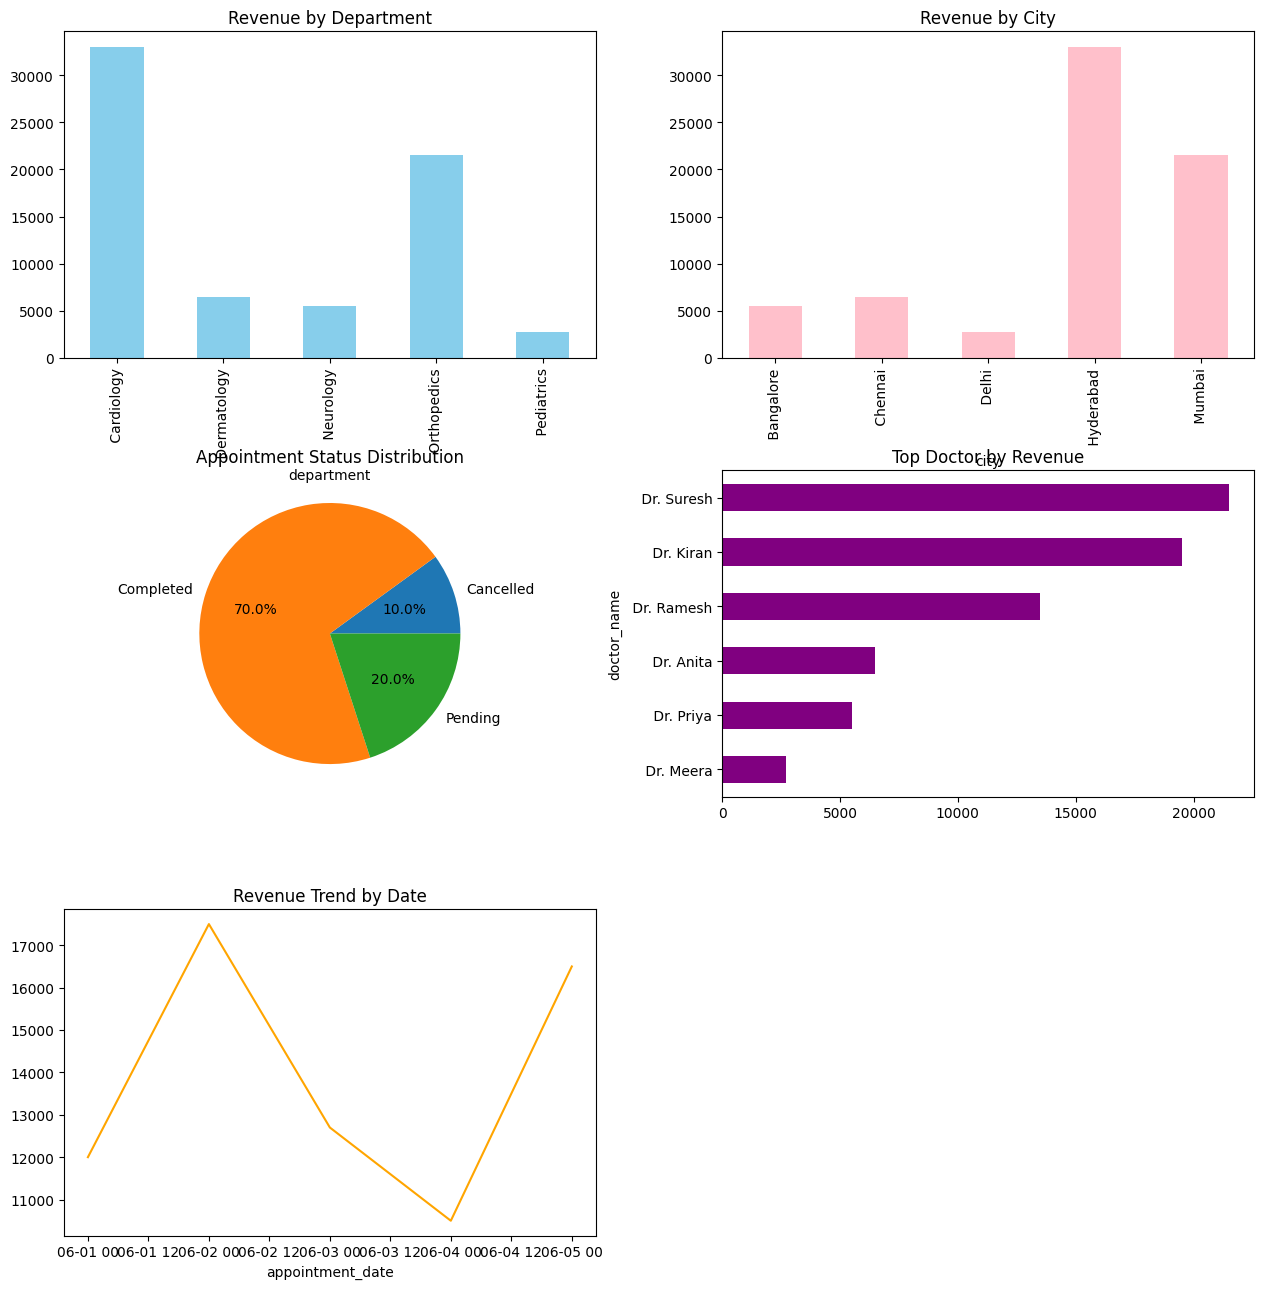

In [0]:
import pandas as pd
import matplotlib.pyplot as plt

hcpdf = spark.sql("SELECT department, city, status, doctor_name, appointment_date, SUM(final_bill) as revenue, COUNT(appointment_id) as total_appointments FROM v_overall_data GROUP BY department, city, status, doctor_name, appointment_date").toPandas()

fig, axes = plt.subplots(3,2, figsize=(14,14))
fig.tight_layout(pad=6.0)

hcpdf.groupby('department')['revenue'].sum().plot(kind='bar', ax=axes[0,0], color='skyblue', title='Revenue by Department')

hcpdf.groupby('city')['revenue'].sum().plot(kind='bar', ax=axes[0,1], color='pink', title='Revenue by City')

hcpdf.groupby('status')['total_appointments'].sum().plot(kind='pie', ax=axes[1,0], autopct='%1.1f%%', title='Appointment Status Distribution').set_ylabel('')

hcpdf.groupby('doctor_name')['revenue'].sum().sort_values().plot(kind='barh', ax=axes[1,1], color='purple', title='Top Doctor by Revenue')

hcpdf.groupby('appointment_date')['revenue'].sum().plot(kind='line', ax=axes[2,0], color='orange', title='Revenue Trend by Date')

axes[2,1].axis('off')
plt.show()

Part 7: Tables and Views


In [0]:
print("Managed Table:")
spark.sql("CREATE TABLE IF NOT EXISTS managed_healthcare_summary AS SELECT city, SUM(final_bill) as total_rev FROM v_overall_data GROUP BY city")
display(spark.sql("SELECT * FROM managed_healthcare_summary"))

print("External Table:")
spark.sql("CREATE TABLE IF NOT EXISTS external_healthcare_summary USING DELTA AS SELECT city, SUM(final_bill) as total_rev FROM v_overall_data GROUP BY city")
display(spark.sql("SELECT * FROM external_healthcare_summary"))

Managed Table:


city,total_rev
Bangalore,5500.0
Chennai,6500.0
Mumbai,21500.0
Delhi,2700.0
Hyderabad,33000.0


External Table:


city,total_rev
Bangalore,5500.0
Chennai,6500.0
Mumbai,21500.0
Delhi,2700.0
Hyderabad,33000.0


In [0]:
overall_data.createOrReplaceTempView("view_overall_data")

In [0]:
overall_data.createOrReplaceGlobalTempView("global_temp.view_overall_data")

---------------------------------------------------------------------------
AnalysisException                         Traceback (most recent call last)
File <command-5752985149673556>, line 1
----> 1 overall_data.createOrReplaceGlobalTempView("global_temp.view_overall_data")

File /databricks/python/lib/python3.12/site-packages/pyspark/sql/connect/dataframe.py:2129, in DataFrame.createOrReplaceGlobalTempView(self, name)
   2125 def createOrReplaceGlobalTempView(self, name: str) -> None:
   2126     command = plan.CreateView(
   2127         child=self._plan, name=name, is_global=True, replace=True
   2128     ).command(session=self._session.client)
-> 2129     _, _, ei = self._session.client.execute_command(command, self._plan.observations)
   2130     self._execution_info = ei

File /databricks/python/lib/python3.12/site-packages/pyspark/sql/connect/client/core.py:1538, in SparkConnectClient.execute_command(self, command, observations, extra_request_metadata)
   1536     req.user_cont

In [0]:
# SCOPE AND LIFETIME COMPARISON
# 1. MANAGED TABLE:
#    Scope: Global (Visible across all workspaces, notebooks, and clusters in the metastore).
#    Lifetime: Persistent (Survives cluster restarts; DROP deletes both metadata and raw files).

# 2. EXTERNAL TABLE:
#    Scope: Global (Visible across all workspaces, notebooks, and clusters in the metastore).
#    Lifetime: Persistent (Survives cluster restarts; DROP deletes ONLY metadata, raw cloud data remains).

# 3. TEMPORARY VIEW:
#    Scope: Session-scoped (Only visible within the specific notebook/spark session that created it).
#    Lifetime: Transient (Automatically dropped when the notebook is detached or cluster restarts).

# 4. GLOBAL TEMPORARY VIEW:
#    Scope: Cluster-scoped (Visible to any notebook or session attached to the SAME running cluster).
#    Lifetime: Transient (Dropped only when the underlying compute cluster restarts or terminates).